# Figures used for Poster Session

### Time series with "visible" regimes

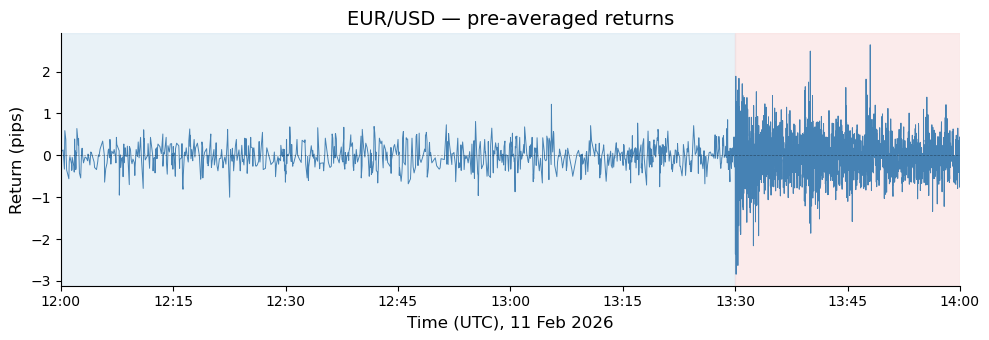

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path().resolve().parent))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from methods.data_utils import load_data, pre_avg, compute_returns, filter_day
from methods.plotting import set_style

set_style(figsize=(10, 3.5))

df = load_data("EURUSD")
pa = pre_avg(df, k=5)
ret = compute_returns(pa)
r_day = filter_day(ret, "2026-02-11")["r"] * 10_000  # basis points

start  = pd.Timestamp("2026-02-11 12:00:00", tz="UTC")
switch = pd.Timestamp("2026-02-11 13:30:00", tz="UTC")
end    = pd.Timestamp("2026-02-11 14:00:00", tz="UTC")
r_zoom = r_day.loc[start:end]

threshold = 5 * r_zoom.std()
r_zoom = r_zoom[r_zoom.abs() < threshold]

fig, ax = plt.subplots()

ax.axvspan(start,  switch, color="#d4e6f1", alpha=0.5)
ax.axvspan(switch, end,    color="#f9d9d9", alpha=0.5)

ax.plot(r_zoom.index, r_zoom.values, color="steelblue", linewidth=0.7)
ax.axhline(0, color="black", linewidth=0.5, linestyle="--", alpha=0.4)

ax.xaxis.set_major_locator(mdates.MinuteLocator(byminute=[0, 15, 30, 45]))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
fig.autofmt_xdate(rotation=0, ha="center")

ax.set_xlim(start, end)
ax.set_xlabel("Time (UTC), 11 Feb 2026")
ax.set_ylabel("Return (pips)")
ax.set_title("EUR/USD — pre-averaged returns")

plt.tight_layout()
# plt.savefig("../plots/POSTER_eurusd_returns_regimes.pdf", bbox_inches="tight", format="pdf")
plt.show()

### Prediction Intervals

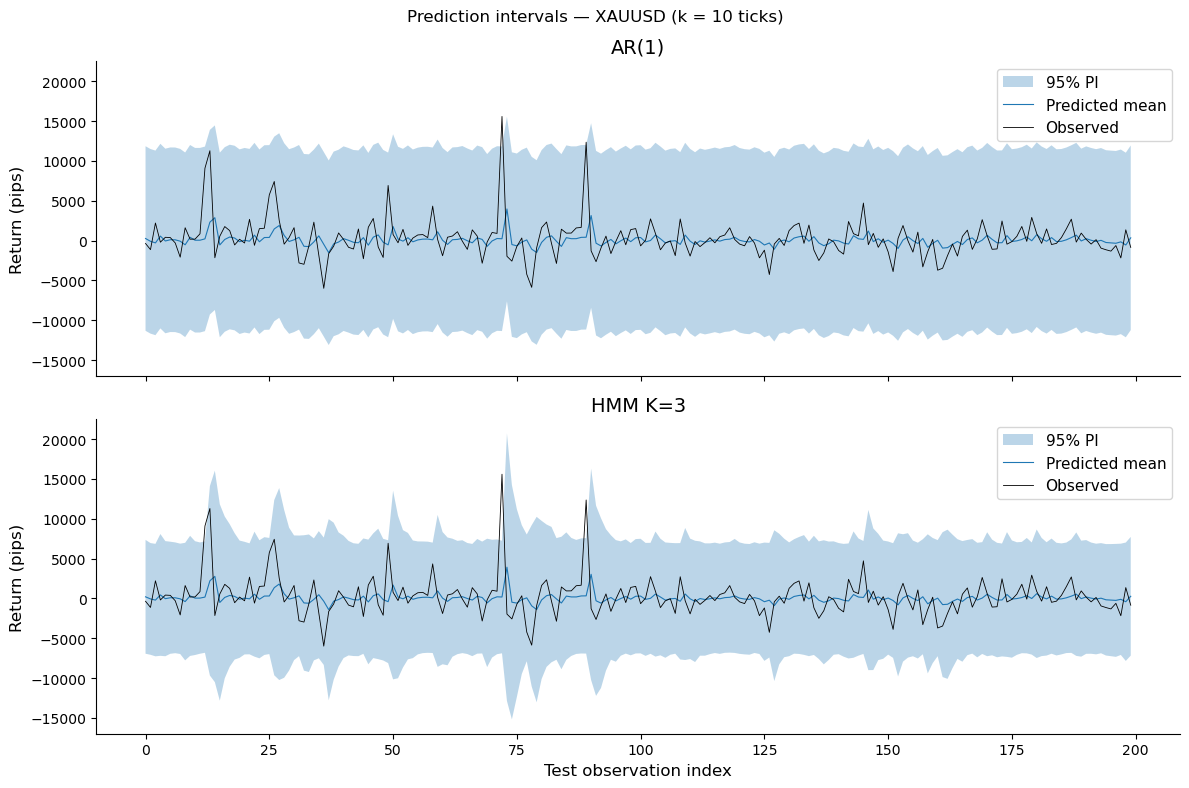

In [3]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path().resolve().parent))

import json
import numpy as np
import matplotlib.pyplot as plt
from methods.data_utils import load_data, pre_avg, compute_returns
from methods.hmm_fast import predict_single_ar1, predict_hmm_mixture
from methods.plotting import set_style

set_style()

N_SHOW  = 200
MARKET  = "XAUUSD"
K_TICKS = 10
K_HMM   = 3

# Load and process data (same pipeline as setup 2)
df_raw  = load_data(MARKET)
pa      = pre_avg(df_raw, tick=True, k=K_TICKS)
ret     = compute_returns(pa)
y_full  = ret["r"].values.astype(float) * 10_000  # pips
split   = int(0.8 * len(y_full))
y_train = y_full[:split]
y_test  = y_full[split:]

# Load fitted parameters from JSON
with open("setup2_results.json") as f:
    results = json.load(f)

ar1_p = results[MARKET]["ar1"]
hmm_r = results[MARKET]["hmm"][str(K_HMM)]
hmm_p = {
    "beta":  np.array(hmm_r["beta"]),
    "sigma": np.array(hmm_r["sigma"]),
    "P":     np.array(hmm_r["P"]),
}

# Generate predictions for the first N_SHOW test observations
y_sub = y_test[:N_SHOW]

ar1_mean, ar1_lo, ar1_hi = predict_single_ar1(
    y_train, y_sub, ar1_p["rho"], ar1_p["sigma"], alpha=0.05
)
hmm_mean, hmm_lo, hmm_hi = predict_hmm_mixture(
    y_train, y_sub, hmm_p, alpha=0.05
)

preds = {
    "AR(1)":        (ar1_mean, ar1_lo, ar1_hi),
    f"HMM K={K_HMM}": (hmm_mean, hmm_lo, hmm_hi),
}

t_plot = np.arange(N_SHOW)

fig, axes = plt.subplots(len(preds), 1, figsize=(12, 4 * len(preds)), sharex=True, sharey=True)

for ax, (label, (pred, lower, upper)) in zip(axes, preds.items()):
    ax.fill_between(t_plot, lower, upper, alpha=0.3, label="95% PI")
    ax.plot(t_plot, pred, linewidth=0.8, label="Predicted mean")
    ax.plot(t_plot, y_sub, linewidth=0.6, color="black", label="Observed")
    ax.set_title(label)
    ax.set_ylabel("Return (pips)")
    ax.legend(loc="upper right")

axes[-1].set_xlabel("Test observation index")
fig.suptitle(f"Prediction intervals — {MARKET} (k = {K_TICKS} ticks)")
plt.tight_layout()
plt.savefig("../plots/POSTERxauusd_prediction_intervals.pdf", bbox_inches="tight", format="pdf")
plt.show()